# 03 - Analyze morphology-predicted transcriptional programs

The notebook is structured into four parts:
- Part 1: Predicted-expression manifold and FUCCI reporter validation
- Part 2: Representative cell-cycle genes and their morphological features
- Part 3: Transcriptional modules and FUCCI-residualized predictability
- Part 4: Module-level morphology, feature responses, and representative cells

Model results are read from `PUBLICATION_RESULTS_DIR`, which defaults to the preprovided files in `./outputs`. To analyze the regenerated notebook-01 files instead, launch the notebook with:

```bash
PUBLICATION_RESULTS_DIR="$PWD/outputs/rerun" jupyter notebook 03_analyze_morphology_predicted_programs.ipynb
```

The static feature matrix has its own `PUBLICATION_FEATURE_MATRIX_PATH`. Regenerated analysis tables are written below the selected results directory and plots to a matching subdirectory under `./figures`, so the two result sources remain isolated.

## Input files

The selected `PUBLICATION_RESULTS_DIR` must contain these precomputed files:
- `rf_gene_metrics.csv`;
- `rf_test_predictions.csv.gz`;
- `cell_metadata.csv`;
- `shap_significant_genes.csv.gz`;
- `individual_gene_fucci_residual_fold_metrics.csv`;
- `individual_gene_fucci_residual_gene_mean_metrics.csv`;
- `individual_gene_fucci_residual_summary.csv`.

Additional inputs are:
- `outputs/features_combined_corrected.csv`, or the path set by `PUBLICATION_FEATURE_MATRIX_PATH`;
- `inputs/FeatureListAnnotated.csv`, used only for representative-cell montages;
- `inputs/fucci_final_nucmask.h5`, or the path set by `FUCCI_H5_PATH`, used only for representative-cell montages.

The montage section is skipped when either optional montage input is unavailable; montage helpers are embedded in this notebook.

This is a publication-only downstream analysis for Figure 5C-K and Supplementary Figure 5D-H. It does not retrain models, repeat residualization, or recompute SHAP values.

In [1]:
# Imports
from pathlib import Path
import os

import pandas as pd

# Select one notebook-01 result folder. Run from the 04_Feature_analysis directory.
ROOT = Path.cwd().resolve()
RESULTS_DIR = Path(
    os.environ.get("PUBLICATION_RESULTS_DIR", ROOT / "outputs")
).expanduser().resolve()
ANALYSIS_OUTPUT_DIR = RESULTS_DIR / "publication_analysis"
FIGURE_DIR = ROOT / "figures" / RESULTS_DIR.name
FEATURE_MATRIX_PATH = Path(
    os.environ.get(
        "PUBLICATION_FEATURE_MATRIX_PATH",
        ROOT / "outputs" / "features_combined_corrected.csv",
    )
).expanduser().resolve()
FEATURE_ANNOTATION_PATH = ROOT / "inputs" / "FeatureListAnnotated.csv"
CELL_IMAGE_H5 = Path(
    os.environ.get("FUCCI_H5_PATH", ROOT / "inputs" / "fucci_final_nucmask.h5")
).expanduser().resolve()
print(f"Reading notebook-01 results from: {RESULTS_DIR}")


Reading notebook-01 results from: /home/bues/iris_DataManagement/geneexp_data/ds_tools/IRIS/2_Cellcycle/04_Feature_analysis/outputs


In [2]:
# Step 1: Validate the selected notebook-01 results and static feature matrix.
INPUT_SCHEMA = {
    RESULTS_DIR / "rf_gene_metrics.csv": ({"gene", "fdr", "avg_Pearson", "n_folds"}, None),
    RESULTS_DIR / "rf_test_predictions.csv.gz": ({"cell_id", "gene", "predicted", "actual"}, None),
    RESULTS_DIR / "cell_metadata.csv": ({"exp_id", "fucci_angular_score", "488_int_mean", "561_int_mean"}, 0),
    RESULTS_DIR / "shap_significant_genes.csv.gz": ({"gene", "feature", "mean_abs_shap"}, None),
    RESULTS_DIR / "individual_gene_fucci_residual_fold_metrics.csv": (
        {"gene", "module", "fold", "condition", "pearson_r", "n_test_cells"}, None
    ),
    RESULTS_DIR / "individual_gene_fucci_residual_gene_mean_metrics.csv": (
        {"gene", "module", "condition", "pearson_r", "n_folds", "delta_r"}, None
    ),
    RESULTS_DIR / "individual_gene_fucci_residual_summary.csv": (
        {
            "module", "n_retained_genes", "median_unresidualized_pearson_r",
            "iqr_unresidualized_pearson_r", "median_fucci_residualized_pearson_r",
            "iqr_fucci_residualized_pearson_r", "median_delta_r",
        },
        None,
    ),
    FEATURE_MATRIX_PATH: (set(), 0),
}

missing_inputs = [path for path in INPUT_SCHEMA if not path.is_file()]
if missing_inputs:
    missing_list = "\n".join(f"  - {path}" for path in missing_inputs)
    raise FileNotFoundError(
        "Publication notebook inputs are missing:\n"
        f"{missing_list}\n"
        "The selected results directory must contain a complete artifact set. "
        "Run notebook 01 before selecting its staged outputs/rerun directory."
    )

schema_errors = []
for path, (required_columns, index_col) in INPUT_SCHEMA.items():
    columns = set(pd.read_csv(path, nrows=0, index_col=index_col).columns)
    absent_columns = sorted(required_columns - columns)
    if absent_columns:
        schema_errors.append(f"{path}: missing columns {absent_columns}")
if schema_errors:
    raise ValueError("Publication input schema validation failed:\n  - " + "\n  - ".join(schema_errors))

print(
    f"Validated {len(INPUT_SCHEMA) - 1} result artifacts from {RESULTS_DIR} "
    f"and feature matrix {FEATURE_MATRIX_PATH}."
)

Validated 7 result artifacts from /home/bues/iris_DataManagement/geneexp_data/ds_tools/IRIS/2_Cellcycle/04_Feature_analysis/outputs and feature matrix /home/bues/iris_DataManagement/geneexp_data/ds_tools/IRIS/2_Cellcycle/04_Feature_analysis/outputs/features_combined_corrected.csv.


In [3]:
# Imports and plot settings

import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import seaborn as sns
from skimage.util import montage as skimage_montage
from IPython.display import display
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import gseapy as gp

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot style
sns.set_context("talk")
sns.set_style("whitegrid")

In [4]:
# Step 2: Load the validated rerun inputs and confirm their internal consistency.
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

rf_gene_metrics = pd.read_csv(RESULTS_DIR / "rf_gene_metrics.csv")
rf_test_predictions = pd.read_csv(RESULTS_DIR / "rf_test_predictions.csv.gz")
cell_metadata = pd.read_csv(RESULTS_DIR / "cell_metadata.csv", index_col=0)
shap_significant_genes = pd.read_csv(RESULTS_DIR / "shap_significant_genes.csv.gz")
individual_gene_fucci_fold_metrics = pd.read_csv(
    RESULTS_DIR / "individual_gene_fucci_residual_fold_metrics.csv"
)
individual_gene_fucci_gene_mean_metrics = pd.read_csv(
    RESULTS_DIR / "individual_gene_fucci_residual_gene_mean_metrics.csv"
)
individual_gene_fucci_summary = pd.read_csv(
    RESULTS_DIR / "individual_gene_fucci_residual_summary.csv"
)
df_features = pd.read_csv(FEATURE_MATRIX_PATH, index_col=0)

cell_metadata.index = cell_metadata.index.astype(str)
df_features.index = df_features.index.astype(str)
rf_gene_metrics["gene"] = rf_gene_metrics["gene"].astype(str)
rf_test_predictions["cell_id"] = rf_test_predictions["cell_id"].astype(str)
rf_test_predictions["gene"] = rf_test_predictions["gene"].astype(str)
shap_significant_genes["gene"] = shap_significant_genes["gene"].astype(str)
shap_significant_genes["feature"] = shap_significant_genes["feature"].astype(str)
observed_batches = set(cell_metadata["exp_id"].dropna().astype(str))
metric_genes = set(rf_gene_metrics["gene"])
fdr_genes = set(rf_gene_metrics.loc[rf_gene_metrics["fdr"] < 0.01, "gene"])
dual_filter_genes = set(
    rf_gene_metrics.loc[
        (rf_gene_metrics["fdr"] < 0.01) & (rf_gene_metrics["avg_Pearson"] > 0.1), "gene"
    ].astype(str)
)
shap_genes = set(shap_significant_genes["gene"].astype(str))
shap_features = set(shap_significant_genes["feature"].astype(str))
quality_errors = []
if rf_gene_metrics.empty or rf_gene_metrics["gene"].isna().any() or not rf_gene_metrics["gene"].is_unique:
    quality_errors.append("rf_gene_metrics.csv must contain non-empty unique gene metrics")
if not rf_gene_metrics["fdr"].between(0, 1).all():
    quality_errors.append("gene-level FDR values must lie in [0, 1]")
if not rf_gene_metrics["avg_Pearson"].dropna().between(-1, 1).all():
    quality_errors.append("gene-level Pearson correlations must lie in [-1, 1]")
if cell_metadata.empty or not cell_metadata.index.is_unique:
    quality_errors.append("cell_metadata.csv must contain unique cells")
if not observed_batches:
    quality_errors.append("cell_metadata.csv must contain at least one experimental batch")
if df_features.empty or not df_features.index.is_unique or df_features.columns.duplicated().any():
    quality_errors.append("feature matrix must have unique cells and feature columns")
if not set(cell_metadata.index).issubset(set(df_features.index)):
    quality_errors.append("feature matrix must contain every rerun metadata cell")
if rf_test_predictions.duplicated(["cell_id", "gene"]).any():
    quality_errors.append("held-out predictions contain duplicate cell/gene rows")
if set(rf_test_predictions["cell_id"]) != set(cell_metadata.index):
    quality_errors.append("held-out predictions and metadata must contain the same cells")
if set(rf_test_predictions["gene"]) != metric_genes:
    quality_errors.append("held-out predictions and gene metrics must contain the same genes")
if len(rf_test_predictions) != len(cell_metadata) * len(metric_genes):
    quality_errors.append("held-out predictions must form a complete cell/gene matrix")
if set(rf_gene_metrics["n_folds"].dropna().astype(int)) != {len(observed_batches)}:
    quality_errors.append("all gene metrics must summarize every observed batch")
if (
    shap_genes != fdr_genes
    or len(shap_significant_genes) != len(shap_genes) * len(shap_features)
    or shap_significant_genes.duplicated(["gene", "feature"]).any()
    or shap_significant_genes[["gene", "feature", "mean_abs_shap"]].isna().any().any()
    or not np.isfinite(shap_significant_genes["mean_abs_shap"]).all()
    or (shap_significant_genes["mean_abs_shap"] < 0).any()
):
    quality_errors.append("SHAP input must be a complete, unique, finite FDR-gene x feature matrix")
if shap_features != set(df_features.columns.astype(str)):
    quality_errors.append("SHAP features must exactly match the loaded feature matrix columns")
if quality_errors:
    raise ValueError("Publication input validation failed:\n  - " + "\n  - ".join(quality_errors))

df_features = df_features.loc[cell_metadata.index].copy()

publication_input_summary = pd.DataFrame({
    "quantity": [
        "gene metrics", "FDR genes", "dual-filter genes", "cells",
        "batches", "SHAP genes", "SHAP features", "SHAP gene-feature pairs",
    ],
    "observed": [
        len(rf_gene_metrics), len(fdr_genes), len(dual_filter_genes), len(cell_metadata),
        cell_metadata["exp_id"].nunique(), len(shap_genes), len(shap_features),
        len(shap_significant_genes),
    ],
})
print(publication_input_summary.to_string(index=False))

               quantity  observed
           gene metrics      2000
              FDR genes       403
      dual-filter genes       187
                  cells      5069
                batches         6
             SHAP genes       403
          SHAP features       277
SHAP gene-feature pairs    111631


# Section 1: Predicted-expression manifold and FUCCI validation

## Figure 5C and Supplementary Figure 5D-E: Predicted-expression manifold

1. Select genes passing `avg_Pearson > 0.1`, align held-out predictions, and standardize expression across cells.
2. Reduce predicted expression by PCA and fit the circular morphology-derived trajectory shown in Figure 5C.
3. Compare the predicted-expression embedding with PCA of the corresponding morphology features.
4. Submit the 50 genes with the largest absolute PC1 and PC2 loadings to Reactome 2022 over-representation analysis.

**Analysis note:** FUCCI is not used to fit the predicted-expression PCA or circle. A constant FUCCI-derived rotation is applied only after fitting to align the displayed phase.

In [5]:
# Step 1: Build the held-out predicted-expression matrix and PCA embedding.
top_predicted = rf_gene_metrics.query("avg_Pearson > 0.1")["gene"].tolist()
if set(top_predicted) != dual_filter_genes or len(top_predicted) < 2:
    raise ValueError("At least two uniquely selected dual-filter genes are required for PCA.")
print("Predictable genes:", len(top_predicted))

predicted_matrix = (
    rf_test_predictions[rf_test_predictions["gene"].isin(top_predicted)]
    .pivot(index="cell_id", columns="gene", values="predicted")
    .reindex(index=cell_metadata.index, columns=top_predicted)
)
metadata_plot = cell_metadata.loc[predicted_matrix.index].copy()
if (
    predicted_matrix.shape != (len(cell_metadata), len(top_predicted))
    or predicted_matrix.isna().any().any()
    or not np.isfinite(predicted_matrix.to_numpy(dtype=float)).all()
):
    raise ValueError(
        f"Expected a complete held-out cell x dual-filter-gene matrix, found {predicted_matrix.shape}."
    )

scaled_predictions = StandardScaler().fit_transform(predicted_matrix)
predicted_expression_pca = PCA(n_components=2, random_state=RANDOM_SEED)
predicted_pcs = predicted_expression_pca.fit_transform(scaled_predictions)
pca_df = pd.DataFrame(predicted_pcs, index=predicted_matrix.index, columns=["PC1", "PC2"])
pca_df["fucci_angular_score"] = metadata_plot["fucci_angular_score"].astype(float)

predicted_expression_pca_loadings = pd.DataFrame(
    predicted_expression_pca.components_.T,
    index=predicted_matrix.columns.astype(str),
    columns=["PC1_loading", "PC2_loading"],
)
predicted_expression_pca_loadings["loading_magnitude"] = np.hypot(
    predicted_expression_pca_loadings["PC1_loading"],
    predicted_expression_pca_loadings["PC2_loading"],
)
predicted_expression_pca_loadings = predicted_expression_pca_loadings.sort_values(
    "loading_magnitude", ascending=False
)
display(predicted_expression_pca_loadings.head(10))

Predictable genes: 187


,PC1_loading,PC2_loading,loading_magnitude
gene,,,
Gas2l3,0.048765,0.143312,0.151382
Arhgap11a,0.061384,0.138302,0.151312
Cenpf,0.067721,0.131716,0.148105
Aurka,0.070978,0.122118,0.141247
Lockd,0.050489,0.131885,0.141219
Cep55,0.065039,0.123916,0.139947
Ckap2l,0.066892,0.121718,0.138888
Parpbp,0.073607,0.117414,0.138579
Ubc,0.044438,-0.130703,0.138050


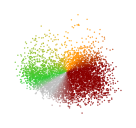

,center_pc1,center_pc2,radius,radius_residual_sd,mean_abs_radius_residual,fucci_posthoc_display_rotation
0,-0.490406,1.994548,10.723811,4.507852,3.789628,2.225703


In [6]:
# Step 2: Fit and display the circular trajectory through predicted-expression PCA.
cc_colors = ["silver", "darkred", "darkred", "darkorange", "orange", "limegreen", "silver", "silver"]
color_stops = [0.0, 0.15, 0.38, 0.5, 0.6, 0.9, 0.95, 1.0]
custom_cmap = LinearSegmentedColormap.from_list(
    "fucci_cell_cycle_palette", list(zip(color_stops, cc_colors))
)
angle_norm = Normalize(vmin=0, vmax=2 * np.pi)


def format_angular_colorbar(colorbar, label="Angular score (theta)"):
    colorbar.set_label(label, fontsize=12, labelpad=12)
    colorbar.set_ticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    colorbar.ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, _: {0: "0", np.pi: "pi", 2 * np.pi: "2pi"}.get(value, ""))
    )


x = pca_df["PC1"].to_numpy(dtype=float)
y = pca_df["PC2"].to_numpy(dtype=float)
fit_matrix = np.column_stack([2 * x, 2 * y, np.ones_like(x)])
fit_target = x ** 2 + y ** 2
center_x, center_y, circle_constant = np.linalg.lstsq(fit_matrix, fit_target, rcond=None)[0]
circle_radius = np.sqrt(circle_constant + center_x ** 2 + center_y ** 2)

pca_df["circle_fit_trajectory_angle_unaligned"] = np.mod(
    np.arctan2(y - center_y, x - center_x), 2 * np.pi
)
fucci_display_rotation = np.angle(
    np.mean(
        np.exp(
            1j
            * (
                pca_df["fucci_angular_score"]
                - pca_df["circle_fit_trajectory_angle_unaligned"]
            )
        )
    )
)
pca_df["circular_trajectory_angle"] = np.mod(
    pca_df["circle_fit_trajectory_angle_unaligned"] + fucci_display_rotation,
    2 * np.pi,
)
pca_df["circular_trajectory_radius"] = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
pca_df["circular_trajectory_radius_residual"] = (
    pca_df["circular_trajectory_radius"] - circle_radius
)

fig, ax = plt.subplots(figsize=(1.5, 1.5))
ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["circular_trajectory_angle"],
    s=1,
    cmap=custom_cmap,
    norm=angle_norm,
    alpha=0.75,
    edgecolors="none",
)
ax.set_aspect("equal", adjustable="box")
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
fig.savefig(FIGURE_DIR / "predicted_expression_pca_angular_score.png", dpi=600, bbox_inches="tight")
plt.show()

display(pd.DataFrame([{
    "center_pc1": center_x,
    "center_pc2": center_y,
    "radius": circle_radius,
    "radius_residual_sd": pca_df["circular_trajectory_radius_residual"].std(),
    "mean_abs_radius_residual": pca_df["circular_trajectory_radius_residual"].abs().mean(),
    "fucci_posthoc_display_rotation": fucci_display_rotation,
}]))

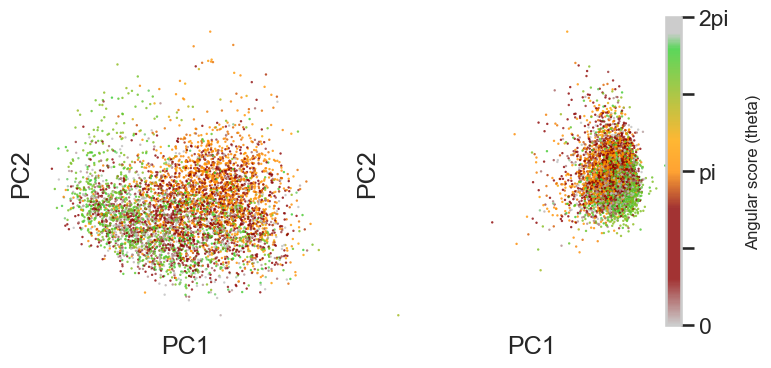

In [7]:
# Step 3: Compare predicted-expression and morphology-feature PCA embeddings.
df_cleaned = df_features.dropna()
scaled_features = StandardScaler().fit_transform(df_cleaned)
feature_pcs = PCA(n_components=2).fit_transform(scaled_features)
df_pca = pd.DataFrame(feature_pcs, columns=["PC1", "PC2"], index=df_cleaned.index)
feature_pca_df = pca_df[["fucci_angular_score"]].join(df_pca, how="inner")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, plot_df in [
    (axes[0], pca_df[["PC1", "PC2", "fucci_angular_score"]].dropna()),
    (axes[1], feature_pca_df.dropna()),
]:
    scatter = ax.scatter(
        plot_df["PC1"], plot_df["PC2"], c=plot_df["fucci_angular_score"],
        s=3, cmap=custom_cmap, norm=angle_norm, alpha=0.8, edgecolors="none"
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
colorbar = fig.colorbar(scatter, ax=axes, fraction=0.046, pad=0.02)
format_angular_colorbar(colorbar)
fig.subplots_adjust(left=0.08, right=0.88, bottom=0.10, top=0.88, wspace=0.18)
fig.savefig(FIGURE_DIR / "raw_feature_vs_pred_trannscr.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1287178/619724939.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


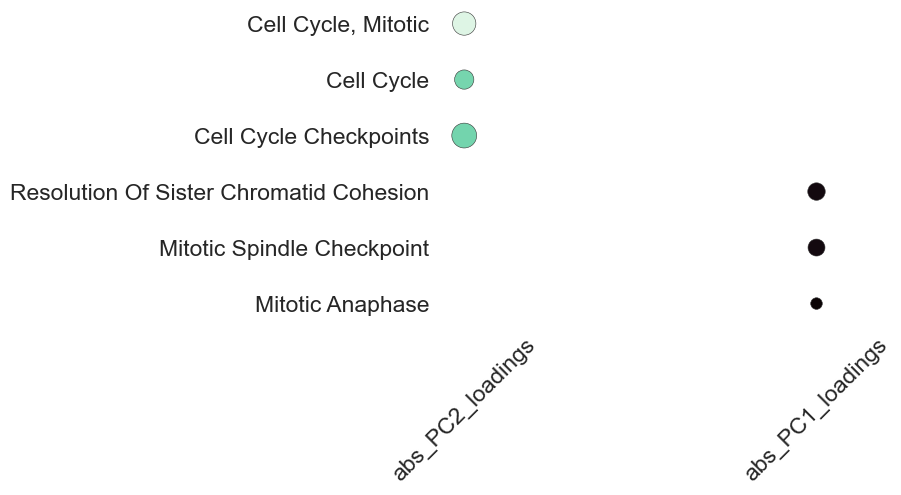

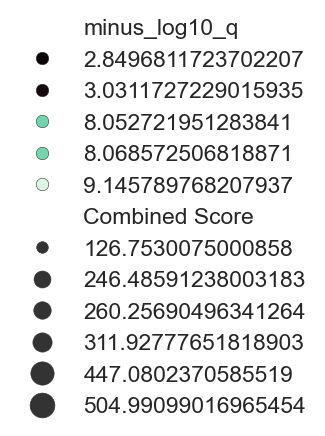

,loading_group,Term,Adjusted P-value,Combined Score
233,abs_PC2_loadings,"Cell Cycle, Mitotic R-HSA-69278",7.148423e-10,447.080237
234,abs_PC2_loadings,Cell Cycle R-HSA-1640170,8.539403e-09,311.927777
235,abs_PC2_loadings,Cell Cycle Checkpoints R-HSA-69620,8.856825e-09,504.990990
0,abs_PC1_loadings,Resolution Of Sister Chromatid Cohesion R-HSA-...,9.307376e-04,260.256905
1,abs_PC1_loadings,Mitotic Spindle Checkpoint R-HSA-69618,9.307376e-04,246.485912
2,abs_PC1_loadings,Mitotic Anaphase R-HSA-68882,1.413575e-03,126.753008


In [8]:
# Step 4: Run Reactome ORA for genes with the largest absolute PCA loadings.
N_TOP_PCA_LOADING_GENES_FOR_ORA = 50
pca_loading_ora_rows = []
for loading_column in ["PC1_loading", "PC2_loading"]:
    loading_group = f"abs_{loading_column.replace('_loading', '')}_loadings"
    genes = (
        predicted_expression_pca_loadings
        .assign(abs_loading=lambda frame: frame[loading_column].abs())
        .sort_values("abs_loading", ascending=False)
        .head(N_TOP_PCA_LOADING_GENES_FOR_ORA)
        .index.astype(str).tolist()
    )
    enrichment = gp.enrichr(
        gene_list=genes,
        gene_sets=["Reactome_2022"],
        organism="Mouse",
        outdir=None,
        cutoff=1.0,
    )
    if enrichment.results is not None and not enrichment.results.empty:
        result = enrichment.results.copy()
        result["loading_group"] = loading_group
        result["n_loading_genes"] = len(genes)
        pca_loading_ora_rows.append(result)

pca_loading_reactome_ora = pd.concat(pca_loading_ora_rows, ignore_index=True)
q_column = "Adjusted P-value" if "Adjusted P-value" in pca_loading_reactome_ora else "P-value"
pca_loading_reactome_ora["minus_log10_q"] = -np.log10(
    pca_loading_reactome_ora[q_column].clip(lower=1e-300)
)
pca_loading_reactome_ora["Term_short"] = (
    pca_loading_reactome_ora["Term"]
    .str.replace(r" \(GO:\d+\)", "", regex=True)
    .str.replace(r"\s+R-[A-Z]+-\d+", "", regex=True)
    .str.slice(0, 55)
)
top_loading_ora = (
    pca_loading_reactome_ora[pca_loading_reactome_ora[q_column] < 0.05]
    .sort_values(q_column)
    .groupby("loading_group", as_index=False)
    .head(3)
)

fig, ax = plt.subplots(figsize=(5, max(4, 0.5 * top_loading_ora["Term_short"].nunique())))
sns.scatterplot(
    data=top_loading_ora,
    x="loading_group",
    y="Term_short",
    hue="minus_log10_q",
    size="Combined Score",
    sizes=(70, 320),
    palette="mako",
    edgecolor="0.2",
    linewidth=0.4,
    ax=ax,
)
loading_legend_handles, loading_legend_labels = ax.get_legend_handles_labels()
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "reactome_ora_predicted_expression_pca_loadings.png", dpi=300, bbox_inches="tight")
plt.show()

legend_fig, legend_ax = plt.subplots(figsize=(3, 4))
legend_ax.axis("off")
legend_ax.legend(
    loading_legend_handles, loading_legend_labels, loc="center", frameon=False
)
legend_fig.tight_layout()
legend_fig.savefig(
    FIGURE_DIR / "reactome_ora_predicted_expression_pca_loadings_legend.png",
    dpi=300, bbox_inches="tight",
)
plt.show()
display(top_loading_ora[["loading_group", "Term", q_column, "Combined Score"]])

### Figure 5D: Independent FUCCI reporter validation

1. Log-transform the two FUCCI reporter channels.
2. Order cells separately by the FUCCI reference angle and the circle-fit trajectory.
3. Calculate centered 500-cell rolling means and independently min-max normalize each trace.

The FUCCI 561 minimum defines a post-hoc common display origin; it does not alter the morphology-derived ordering.

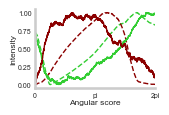

In [9]:
# Compare smoothed FUCCI reporters along reference and morphology-derived angles.
reporter_cols = ["488_int_mean", "561_int_mean"]
angle_specs = [
    ("fucci_angular_score", "FUCCI reference angle", "--"),
    ("circular_trajectory_angle", "Circle-fit trajectory angle", "-"),
]
reporter_df = pca_df[[column for column, _, _ in angle_specs]].join(
    metadata_plot[reporter_cols].astype(float), how="inner"
)
for column in reporter_cols:
    reporter_df[f"log_{column}"] = np.log1p(reporter_df[column])

ROLLING_WINDOW = 500
MIN_ROLLING_PERIODS = max(5, ROLLING_WINDOW // 4)
fucci_ordered = reporter_df.sort_values("fucci_angular_score")
fucci_561_rolling = fucci_ordered["log_561_int_mean"].rolling(
    ROLLING_WINDOW, center=True, min_periods=MIN_ROLLING_PERIODS
).mean()
fucci_561_min_angle = fucci_ordered["fucci_angular_score"].to_numpy(dtype=float)[
    int(np.nanargmin(fucci_561_rolling))
]

reporter_palette = {"488_int_mean": "limegreen", "561_int_mean": "darkred"}
fig, ax = plt.subplots(figsize=(2.0, 1.5))
for angle_column, angle_label, linestyle in angle_specs:
    display_angle = np.mod(reporter_df[angle_column] - fucci_561_min_angle, 2 * np.pi)
    ordered = reporter_df.assign(display_angle=display_angle).sort_values("display_angle")
    plot_x = np.linspace(0, 2 * np.pi, len(ordered))
    for reporter_column in reporter_cols:
        rolling_mean = ordered[f"log_{reporter_column}"].rolling(
            ROLLING_WINDOW, center=True, min_periods=MIN_ROLLING_PERIODS
        ).mean()
        normalized = (rolling_mean - rolling_mean.min()) / (rolling_mean.max() - rolling_mean.min())
        ax.plot(
            plot_x, normalized, linewidth=1, linestyle=linestyle,
            color=reporter_palette[reporter_column], label=f"{reporter_column} ({angle_label})"
        )
ax.set_xlabel("Angular score", fontsize=6, labelpad=1)
ax.set_ylabel("Intensity", fontsize=6, labelpad=1)
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks([0, np.pi, 2 * np.pi], ["0", "pi", "2pi"])
ax.tick_params(axis="both", labelsize=5, pad=0.5, length=2, width=0.5)
ax.grid(False)
for spine_name in ["top", "right"]:
    ax.spines[spine_name].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fucci_reporters_by_fucci_angle_and_circle_fit_trajectory.png", dpi=600, bbox_inches="tight")
plt.show()

# Section 2: Representative genes and morphological features

## Figure 5E-F: Representative cell-cycle genes

1. Retain the publication genes Sox9, Top2a, Hist1h1b, Cenpe, and Aspm when present in the rerun predictions, independently of their new significance status.
2. Independently z-score predicted and measured expression and smooth both profiles in FUCCI-angle order.
3. Retrieve and display the three largest mean-absolute-SHAP features for each representative gene.

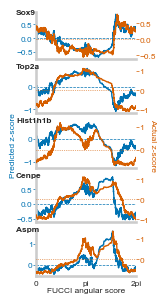

In [10]:
# Step 1: Plot measured and predicted profiles for representative genes.
representative_genes = [
    gene for gene in ["Sox9", "Top2a", "Hist1h1b", "Cenpe", "Aspm"]
    if gene in metric_genes
]
if not representative_genes:
    raise ValueError("None of the five publication representative genes are available.")

representative_predictions = rf_test_predictions[
    rf_test_predictions["gene"].isin(representative_genes)
]
actual_gene_matrix = representative_predictions.pivot(
    index="cell_id", columns="gene", values="actual"
).reindex(index=cell_metadata.index, columns=representative_genes)
predicted_gene_matrix = representative_predictions.pivot(
    index="cell_id", columns="gene", values="predicted"
).reindex(index=cell_metadata.index, columns=representative_genes)
if actual_gene_matrix.isna().any().any() or predicted_gene_matrix.isna().any().any():
    raise ValueError("Representative-gene predictions must cover the complete rerun cohort.")
fucci_angle_df = pca_df[["fucci_angular_score"]].copy()
actual_gene_trends = actual_gene_matrix.join(fucci_angle_df).dropna(subset=["fucci_angular_score"])
predicted_gene_trends = predicted_gene_matrix.join(fucci_angle_df).dropna(
    subset=["fucci_angular_score"]
)

fig, axes = plt.subplots(
    len(representative_genes), 1, figsize=(2.0, 0.6 * len(representative_genes)), sharex=True
)
axes = np.atleast_1d(axes)
for ax, gene in zip(axes, representative_genes):
    actual_ax = ax.twinx()
    predicted_df = predicted_gene_trends[[gene, "fucci_angular_score"]].dropna().sort_values("fucci_angular_score")
    actual_df = actual_gene_trends[[gene, "fucci_angular_score"]].dropna().sort_values("fucci_angular_score")
    predicted_z = (predicted_df[gene] - predicted_df[gene].mean()) / predicted_df[gene].std()
    actual_z = (actual_df[gene] - actual_df[gene].mean()) / actual_df[gene].std()
    predicted_trend = predicted_z.rolling(max(25, len(predicted_df) // 50), center=True, min_periods=5).mean()
    actual_trend = actual_z.rolling(max(25, len(actual_df) // 50), center=True, min_periods=5).mean()
    ax.plot(predicted_df["fucci_angular_score"], predicted_trend, linewidth=1, color="#0072B2")
    actual_ax.plot(actual_df["fucci_angular_score"], actual_trend, linewidth=1, color="#D55E00")
    ax.axhline(0, color="#0072B2", linewidth=0.5, linestyle="--")
    actual_ax.axhline(0, color="#D55E00", linewidth=0.5, linestyle=":")
    ax.text(-0.2, 0.96, gene, transform=ax.transAxes, fontsize=6, fontweight="bold")
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi, 2 * np.pi], ["0", "pi", "2pi"])
    ax.grid(False)
    actual_ax.grid(False)
    for spine_name in ["top", "right"]:
        ax.spines[spine_name].set_visible(False)
    for spine in actual_ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", labelsize=6, pad=0.5, length=2, width=0.5)
    actual_ax.tick_params(axis="y", labelsize=6, pad=0.5, length=2, width=0.5, colors="#D55E00")
    ax.tick_params(axis="y", colors="#0072B2")
axes[-1].set_xlabel("FUCCI angular score", fontsize=6, labelpad=1)
fig.subplots_adjust(left=0.28, right=0.78, bottom=0.10, top=0.98, hspace=0.15)
fig.text(0.15, 0.54, "Predicted z-score", rotation=90, color="#0072B2", fontsize=6, va="center")
fig.text(0.85, 0.54, "Actual z-score", rotation=270, color="#D55E00", fontsize=6, va="center")
fig.savefig(FIGURE_DIR / "actual_predicted_gene_dynamics_individual_by_fucci_angle.png", dpi=600, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1287178/4043735224.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


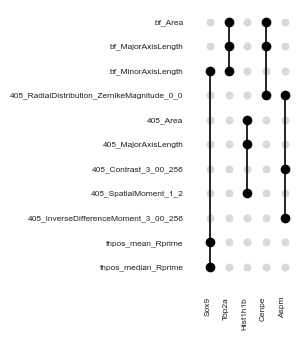

,gene,feature,mean_abs_shap
2773,Aspm,405_Contrast_3_00_256,0.014349
2771,Aspm,405_RadialDistribution_ZernikeMagnitude_0_0,0.013180
2774,Aspm,405_InverseDifferenceMoment_3_00_256,0.010014
1998,Cenpe,bf_Area,0.025481
1940,Cenpe,405_RadialDistribution_ZernikeMagnitude_0_0,0.021096
1997,Cenpe,bf_MajorAxisLength,0.020797
6963,Hist1h1b,405_Area,0.016994
6961,Hist1h1b,405_MajorAxisLength,0.016667
6962,Hist1h1b,405_SpatialMoment_1_2,0.013488
12525,Sox9,bf_MinorAxisLength,0.008745


In [11]:
# Step 2: Display rerun-ranked mean-absolute-SHAP features for each available gene.
representative_shap = (
    shap_significant_genes[shap_significant_genes["gene"].isin(representative_genes)]
    .sort_values(["gene", "mean_abs_shap", "feature"], ascending=[True, False, True])
    .groupby("gene", as_index=False).head(3)
)
if representative_shap.empty:
    raise ValueError("No publication representative gene is present in the rerun SHAP table.")
representative_shap_genes = [
    gene for gene in representative_genes if gene in set(representative_shap["gene"])
]
feature_order = (
    representative_shap.groupby("feature", as_index=False)["mean_abs_shap"].max()
    .sort_values(["mean_abs_shap", "feature"], ascending=[False, True])["feature"].tolist()
)
membership = pd.crosstab(representative_shap["feature"], representative_shap["gene"]).reindex(
    index=feature_order, columns=representative_shap_genes, fill_value=0
)

fig, ax = plt.subplots(figsize=(1.2, 3.5))
for x_index, gene in enumerate(membership.columns):
    active_y = []
    for y_index, feature in enumerate(membership.index):
        active = membership.loc[feature, gene] > 0
        ax.scatter(x_index, y_index, s=30 if active else 18, color="black" if active else "0.85")
        if active:
            active_y.append(y_index)
    if len(active_y) > 1:
        ax.plot([x_index] * len(active_y), active_y, color="black", linewidth=1.2)
ax.set_xticks(range(len(membership.columns)), membership.columns, rotation=90, ha="right", fontsize=6)
ax.set_yticks(range(len(membership.index)), membership.index, fontsize=6)
ax.set_xlim(-0.5, len(membership.columns) - 0.5)
ax.set_ylim(len(membership.index) - 0.5, -0.5)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "top_shap_feature_gene_membership_upset_transposed.png", dpi=300, bbox_inches="tight")
plt.show()
display(representative_shap)

# Section 3: Transcriptional modules and residualized predictability

## Figure 5G-H and Supplementary Figure 5F: Transcriptional modules

1. Standardize predicted expression by gene and reduce it with the original six-component PCA.
2. Assign genes to three KMeans clusters (`n_init=50`, seed 0) and label arbitrary cluster IDs by maximum overlap with the rerun Cell Cycle and Contractility reference sets.
3. Run Reactome 2022 over-representation analysis on each complete module gene list.
4. Reconstruct the FUCCI-residualized comparison from saved per-gene fold-mean correlations.

**Analysis note:** reference sets do not enter PCA or KMeans fitting. They label clusters afterward through a one-to-one maximum-overlap assignment; overlap is reported rather than required to reproduce historical memberships. Supplementary Figure 5F reports medians of signed per-gene ratios (`residualized mean held-out Pearson r / unresidualized mean held-out Pearson r`), not a generic accuracy metric or a ratio of group medians.

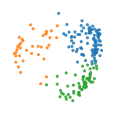

/tmp/ipykernel_1287178/285558759.py:188: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


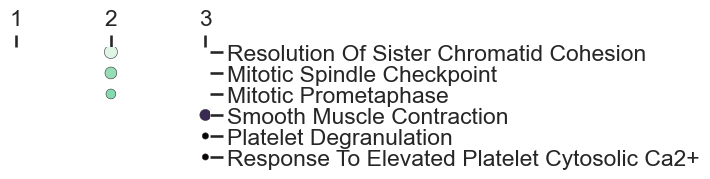

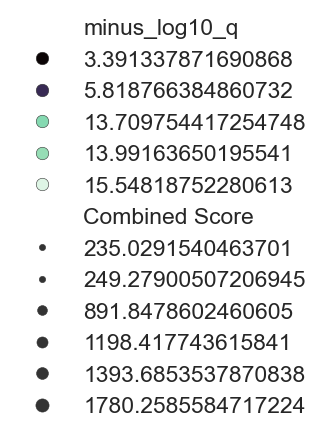

,kmeans_raw_cluster,reference_module,n_cluster_genes,n_reference_genes,overlap,reference_recall,jaccard,assigned
0,0,Cell Cycle,59,91,0,0.0,0.0,False
1,0,Contractility,59,59,59,1.0,1.0,True
2,1,Cell Cycle,91,91,91,1.0,1.0,True
3,1,Contractility,91,59,0,0.0,0.0,False
4,2,Cell Cycle,37,91,0,0.0,0.0,False
5,2,Contractility,37,59,0,0.0,0.0,False


canonical_cluster  cluster_label  
1                  1 Unknown          37
2                  2 Cell Cycle       91
3                  3 Contractility    59
Name: n_genes, dtype: int64

,cluster_label,Term,Adjusted P-value,Combined Score
224,2 Cell Cycle,Resolution Of Sister Chromatid Cohesion R-HSA-...,2.830170e-16,1780.258558
225,2 Cell Cycle,Mitotic Spindle Checkpoint R-HSA-69618,1.019444e-14,1393.685354
226,2 Cell Cycle,Mitotic Prometaphase R-HSA-68877,1.950948e-14,891.847860
499,3 Contractility,Smooth Muscle Contraction R-HSA-445355,1.517867e-06,1198.417744
500,3 Contractility,Platelet Degranulation R-HSA-114608,4.061272e-04,249.279005
501,3 Contractility,Response To Elevated Platelet Cytosolic Ca2+ R...,4.061272e-04,235.029154


In [12]:
# Step 1: Cluster predicted gene profiles and assign canonical module labels.
N_MODULES = 3
N_MODULE_PCS = 6
cluster_column = "canonical_cluster"

predicted_gene_z = predicted_matrix.T.dropna(axis=1, how="any").copy()
predicted_gene_z = predicted_gene_z.sub(predicted_gene_z.mean(axis=1), axis=0)
predicted_gene_z = predicted_gene_z.div(
    predicted_matrix.T.std(axis=1).replace(0, np.nan), axis=0
).fillna(0)
if min(predicted_gene_z.shape) < N_MODULE_PCS:
    raise ValueError("Six-PC module clustering requires at least six genes and six cells.")
module_pca = PCA(n_components=N_MODULE_PCS, random_state=0)
module_pcs = module_pca.fit_transform(StandardScaler().fit_transform(predicted_gene_z))
predicted_gene_clusters = pd.DataFrame({
    "gene": predicted_gene_z.index.astype(str),
    "kmeans_raw_cluster": KMeans(
        n_clusters=N_MODULES, n_init=50, random_state=0
    ).fit_predict(module_pcs),
})

reference_gene_modules = individual_gene_fucci_gene_mean_metrics[
    ["gene", "module"]
].drop_duplicates()
reference_gene_modules["gene"] = reference_gene_modules["gene"].astype(str)
if reference_gene_modules["gene"].duplicated().any():
    raise ValueError("A canonical reference gene is assigned to more than one module.")
reference_sets = {
    module: set(group["gene"].astype(str))
    for module, group in reference_gene_modules.groupby("module")
}
if not reference_sets or len(reference_sets) >= N_MODULES:
    raise ValueError("Reference modules must be non-empty and fewer than the KMeans clusters.")
reference_module_order = [
    module for module in ["Cell Cycle", "Contractility"] if module in reference_sets
] + sorted(set(reference_sets) - {"Cell Cycle", "Contractility"})
raw_cluster_sets = {
    raw_id: set(group["gene"])
    for raw_id, group in predicted_gene_clusters.groupby("kmeans_raw_cluster")
}
raw_cluster_order = sorted(raw_cluster_sets)
overlap_matrix = np.array([
    [len(raw_cluster_sets[raw_id] & reference_sets[module]) for module in reference_module_order]
    for raw_id in raw_cluster_order
])
assigned_rows, assigned_columns = linear_sum_assignment(-overlap_matrix)
raw_to_label = {
    raw_cluster_order[row]: reference_module_order[column]
    for row, column in zip(assigned_rows, assigned_columns)
}
unmatched_raw_ids = [raw_id for raw_id in raw_cluster_order if raw_id not in raw_to_label]
for raw_id in unmatched_raw_ids:
    raw_to_label[raw_id] = (
        "Unknown" if len(unmatched_raw_ids) == 1 else f"Unassigned {raw_id}"
    )
unmatched_labels = [raw_to_label[raw_id] for raw_id in unmatched_raw_ids]
canonical_label_order = unmatched_labels + reference_module_order
canonical_id_by_label = {label: index + 1 for index, label in enumerate(canonical_label_order)}
raw_to_canonical = {
    raw_id: canonical_id_by_label[label] for raw_id, label in raw_to_label.items()
}
MODULE_LABELS = {
    canonical_id: f"{canonical_id} {label}"
    for label, canonical_id in canonical_id_by_label.items()
}
module_order = sorted(MODULE_LABELS)

overlap_rows = []
for raw_id, cluster_genes in raw_cluster_sets.items():
    for module, reference_genes in reference_sets.items():
        overlap = len(cluster_genes & reference_genes)
        overlap_rows.append({
            "kmeans_raw_cluster": raw_id,
            "reference_module": module,
            "n_cluster_genes": len(cluster_genes),
            "n_reference_genes": len(reference_genes),
            "overlap": overlap,
            "reference_recall": overlap / len(reference_genes),
            "jaccard": overlap / len(cluster_genes | reference_genes),
            "assigned": raw_to_label[raw_id] == module,
        })
module_reference_overlaps = pd.DataFrame(overlap_rows)
module_mapping = pd.DataFrame([
    {
        "kmeans_raw_cluster": raw_id,
        cluster_column: raw_to_canonical[raw_id],
        "module_name": raw_to_label[raw_id],
        "cluster_label": MODULE_LABELS[raw_to_canonical[raw_id]],
    }
    for raw_id in raw_cluster_order
])
predicted_gene_clusters[cluster_column] = predicted_gene_clusters["kmeans_raw_cluster"].map(
    raw_to_canonical
)
predicted_gene_clusters["cluster_label"] = predicted_gene_clusters[cluster_column].map(MODULE_LABELS)
predicted_gene_clusters["reference_module"] = predicted_gene_clusters["gene"].map(
    reference_gene_modules.set_index("gene")["module"]
).fillna("")
predicted_gene_clusters.to_csv(
    ANALYSIS_OUTPUT_DIR / "predicted_gene_canonical_assignments.csv", index=False
)
module_mapping.to_csv(ANALYSIS_OUTPUT_DIR / "predicted_gene_cluster_mapping.csv", index=False)
module_reference_overlaps.to_csv(
    ANALYSIS_OUTPUT_DIR / "predicted_gene_cluster_reference_overlaps.csv", index=False
)
module_pca_df = pd.DataFrame(
    module_pcs[:, :2], columns=["PredExpr_PC1", "PredExpr_PC2"]
).join(predicted_gene_clusters)

fig, ax = plt.subplots(figsize=(1.5, 1.5))
sns.scatterplot(
    data=module_pca_df, x="PredExpr_PC1", y="PredExpr_PC2", hue="cluster_label",
    palette="tab10", s=5, alpha=0.85, linewidth=0, ax=ax
)
ax.legend_.remove()
ax.grid(False)
ax.set(xticks=[], yticks=[], xlabel="", ylabel="")
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "predicted_expression_gene_zpca_kmeans_pca.png", dpi=600, bbox_inches="tight")
plt.show()

module_ora_rows = []
module_ora_errors = []
for cluster_id, group in predicted_gene_clusters.groupby(cluster_column):
    genes = group["gene"].tolist()
    try:
        enrichment = gp.enrichr(
            gene_list=genes, gene_sets=["Reactome_2022"], organism="Mouse",
            outdir=None, cutoff=1.0
        )
    except Exception as exc:
        module_ora_errors.append({"cluster": cluster_id, "error": str(exc)})
        continue
    if enrichment.results is not None and not enrichment.results.empty:
        result = enrichment.results.copy()
        result[cluster_column] = cluster_id
        result["cluster_label"] = MODULE_LABELS[cluster_id]
        module_ora_rows.append(result)
module_reactome_ora = (
    pd.concat(module_ora_rows, ignore_index=True) if module_ora_rows else pd.DataFrame()
)
pd.DataFrame(module_ora_errors, columns=["cluster", "error"]).to_csv(
    ANALYSIS_OUTPUT_DIR / "predicted_gene_module_ora_errors.csv", index=False
)
module_reactome_ora.to_csv(
    ANALYSIS_OUTPUT_DIR / "predicted_gene_module_reactome_ora.csv", index=False
)
module_top_terms = pd.DataFrame()
if not module_reactome_ora.empty:
    q_column = (
        "Adjusted P-value" if "Adjusted P-value" in module_reactome_ora else "P-value"
    )
    module_top_terms = (
        module_reactome_ora.sort_values(q_column)
        .groupby(cluster_column, as_index=False).head(3)
    )
    module_top_terms = module_top_terms[module_top_terms[q_column] < 0.05].copy()
if not module_top_terms.empty:
    module_top_terms["minus_log10_q"] = -np.log10(
        module_top_terms[q_column].clip(lower=1e-300)
    )
    module_top_terms["Term_short"] = (
        module_top_terms["Term"]
        .str.replace(r" \(GO:\d+\)", "", regex=True)
        .str.replace(r"\s+R-[A-Z]+-\d+", "", regex=True)
        .str.slice(0, 55)
    )
    fig, ax = plt.subplots(
        figsize=(2.5, max(1.5, 0.25 * module_top_terms["Term_short"].nunique()))
    )
    sns.scatterplot(
        data=module_top_terms, x=cluster_column, y="Term_short",
        hue="minus_log10_q", size="Combined Score", sizes=(20, 90), palette="mako",
        edgecolor="0.2", linewidth=0.4, ax=ax
    )
    module_legend_handles, module_legend_labels = ax.get_legend_handles_labels()
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_xticks(module_order, [str(value) for value in module_order])
    ax.set(xlabel="", ylabel="")
    ax.yaxis.tick_right()
    ax.xaxis.set_ticks_position("top")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "reactome_ora_predicted_expression_modules.png",
        dpi=600, bbox_inches="tight"
    )
    plt.show()

    legend_fig, legend_ax = plt.subplots(figsize=(3, 4))
    legend_ax.axis("off")
    legend_ax.legend(
        module_legend_handles, module_legend_labels, loc="center", frameon=False
    )
    legend_fig.tight_layout()
    legend_fig.savefig(
        FIGURE_DIR / "reactome_ora_predicted_expression_modules_legend.png",
        dpi=600, bbox_inches="tight",
    )
    plt.show()
else:
    print("No significant module-level Reactome terms returned for this rerun.")
display(module_reference_overlaps)
display(predicted_gene_clusters.groupby([cluster_column, "cluster_label"]).size().rename("n_genes"))
if not module_top_terms.empty:
    display(module_top_terms[["cluster_label", "Term", q_column, "Combined Score"]])

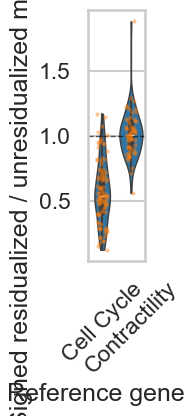

,n_genes,median_signed_per_gene_ratio,median_signed_per_gene_ratio_percent
module,,,
Cell Cycle,91,0.541612,54.161204
Contractility,59,1.011106,101.110611


In [13]:
# Step 2: Summarize per-gene FUCCI-residualized predictability.
CONDITION_ORDER = ["Unresidualized", "FUCCI residualized"]
mean_metrics = individual_gene_fucci_gene_mean_metrics.copy()
if mean_metrics.duplicated(["gene", "module", "condition"]).any():
    raise ValueError("Per-gene mean metrics contain duplicate gene/module/condition rows.")
residual_module_order = [
    module for module in ["Cell Cycle", "Contractility"]
    if module in set(mean_metrics["module"])
] + sorted(set(mean_metrics["module"]) - {"Cell Cycle", "Contractility"})
condition_sets = mean_metrics.groupby(["gene", "module"])["condition"].apply(set)
if condition_sets.empty or not condition_sets.map(lambda values: values == set(CONDITION_ORDER)).all():
    raise ValueError("Every per-gene mean must contain both residualization conditions.")
fold_sets = individual_gene_fucci_fold_metrics.groupby(
    ["gene", "module", "condition"]
)["fold"].apply(lambda values: set(values.astype(str)))
if not fold_sets.map(lambda values: values == observed_batches).all():
    raise ValueError("Every per-gene condition must contain every observed batch fold.")
if not mean_metrics["n_folds"].astype(int).eq(len(observed_batches)).all():
    raise ValueError("Every per-gene mean must summarize every observed batch fold.")

individual_gene_fucci_ratios = (
    mean_metrics.pivot(index=["gene", "module"], columns="condition", values="pearson_r")
    .dropna(subset=CONDITION_ORDER)
    .reset_index()
    .rename(columns={
        "Unresidualized": "unresidualized_mean_held_out_r",
        "FUCCI residualized": "fucci_residualized_mean_held_out_r",
    })
)
if individual_gene_fucci_ratios["unresidualized_mean_held_out_r"].abs().le(1e-8).any():
    raise ValueError("A near-zero unresidualized mean held-out r makes a per-gene ratio undefined.")
individual_gene_fucci_ratios["residualized_to_unresidualized_mean_held_out_r_ratio"] = (
    individual_gene_fucci_ratios["fucci_residualized_mean_held_out_r"]
    / individual_gene_fucci_ratios["unresidualized_mean_held_out_r"]
)
individual_gene_fucci_ratios["delta_r"] = (
    individual_gene_fucci_ratios["fucci_residualized_mean_held_out_r"]
    - individual_gene_fucci_ratios["unresidualized_mean_held_out_r"]
)
ratio_column = "residualized_to_unresidualized_mean_held_out_r_ratio"
if not np.isfinite(individual_gene_fucci_ratios[ratio_column]).all():
    raise ValueError("All signed per-gene residualized/unresidualized ratios must be finite.")

ratio_summary = (
    individual_gene_fucci_ratios.groupby("module")[ratio_column]
    .agg(n_genes="size", median_signed_per_gene_ratio="median")
    .reindex(residual_module_order)
)
summary_indexed = individual_gene_fucci_summary.set_index("module")
detail_counts = individual_gene_fucci_ratios.groupby("module")["gene"].nunique().to_dict()
if summary_indexed["n_retained_genes"].astype(int).to_dict() != detail_counts:
    raise ValueError("Saved per-gene summary counts disagree with the rerun detail table.")
for module, group in individual_gene_fucci_ratios.groupby("module"):
    if not np.isclose(
        group["unresidualized_mean_held_out_r"].median(),
        summary_indexed.loc[module, "median_unresidualized_pearson_r"],
    ) or not np.isclose(
        group["fucci_residualized_mean_held_out_r"].median(),
        summary_indexed.loc[module, "median_fucci_residualized_pearson_r"],
    ):
        raise ValueError(f"Saved and recomputed per-gene summaries disagree for {module}.")

individual_gene_fucci_ratios.to_csv(
    ANALYSIS_OUTPUT_DIR / "supplementary_fig_5f_individual_gene_signed_r_ratios.csv",
    index=False
)
fig, ax = plt.subplots(figsize=(2, 4.5))
sns.violinplot(
    data=individual_gene_fucci_ratios, x="module", y=ratio_column,
    order=residual_module_order, cut=0, inner="box", linewidth=1, ax=ax,
)
sns.stripplot(
    data=individual_gene_fucci_ratios, x="module", y=ratio_column,
    order=residual_module_order, jitter=0.18, alpha=0.45,
    size=3, linewidth=0, ax=ax,
)
ax.axhline(1, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Reference gene set")
ax.set_ylabel("Signed residualized / unresidualized mean held-out r")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "supplementary_fig_5f_individual_gene_signed_r_ratios.png",
    dpi=300, bbox_inches="tight",
)
plt.show()
ratio_summary["median_signed_per_gene_ratio_percent"] = (
    100 * ratio_summary["median_signed_per_gene_ratio"]
)
display(ratio_summary)

### Figure 5I and Supplementary Figure 5G: Module-level morphology

1. Normalize mean absolute SHAP values within each gene.
2. Average normalized SHAP values by transcriptional module and display the top three features per module.
3. Calculate the Spearman feature-correlation matrix for the selected publication features.

/tmp/ipykernel_1287178/3626901563.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


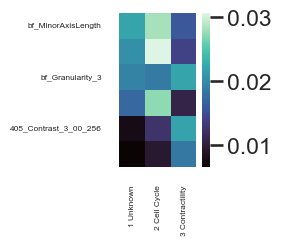

,canonical_cluster,feature,mean_normalized_shap,median_normalized_shap,n_genes
174,1,bf_MinorAxisLength,0.022113,0.021056,37
144,1,bf_Area,0.020429,0.021107,37
164,1,bf_Granularity_3,0.019215,0.013254,37
421,2,bf_Area,0.030636,0.028915,91
451,2,bf_MinorAxisLength,0.028101,0.026922,91
450,2,bf_MajorAxisLength,0.027286,0.028088,91
718,3,bf_Granularity_3,0.022154,0.014481,59
565,3,405_Contrast_3_00_256,0.021917,0.022018,59
599,3,405_InverseDifferenceMoment_3_00_256,0.018322,0.018632,59


In [14]:
# Step 1: Aggregate normalized rerun SHAP values by transcriptional module.
module_shap = shap_significant_genes.merge(
    predicted_gene_clusters[["gene", cluster_column]], on="gene", how="inner"
)
if module_shap.empty:
    raise ValueError("No clustered predictable genes are present in the SHAP summary.")
gene_shap_totals = module_shap.groupby("gene")["mean_abs_shap"].transform("sum")
module_shap["normalized_mean_abs_shap"] = np.where(
    gene_shap_totals > 0, module_shap["mean_abs_shap"] / gene_shap_totals, np.nan
)
module_feature_scores = (
    module_shap.groupby([cluster_column, "feature"], as_index=False)
    .agg(
        mean_normalized_shap=("normalized_mean_abs_shap", "mean"),
        median_normalized_shap=("normalized_mean_abs_shap", "median"),
        n_genes=("gene", "nunique"),
    )
)
top3_module_features = (
    module_feature_scores.sort_values(
        [cluster_column, "mean_normalized_shap", "feature"],
        ascending=[True, False, True],
    )
    .groupby(cluster_column, as_index=False).head(3)
)
top_module_features = top3_module_features["feature"].drop_duplicates().tolist()
best_shap_cluster_by_feature = (
    module_feature_scores[module_feature_scores["feature"].isin(top_module_features)]
    .sort_values(
        ["feature", "mean_normalized_shap", cluster_column],
        ascending=[True, False, True],
    )
    .groupby("feature", as_index=False).head(1)
    [["feature", cluster_column, "mean_normalized_shap"]]
    .rename(columns={cluster_column: "best_shap_cluster"})
)
ordered_module_features = top_module_features
module_shap_matrix = (
    module_feature_scores.pivot_table(
        index=cluster_column, columns="feature", values="mean_normalized_shap", aggfunc="mean"
    )
    .reindex(index=module_order, columns=ordered_module_features).fillna(0)
)
module_shap_matrix.index = [MODULE_LABELS[index] for index in module_shap_matrix.index]

fig, ax = plt.subplots(figsize=(max(1.5, 0.45 * len(module_order)), max(2, 0.3 * len(ordered_module_features))))
sns.heatmap(module_shap_matrix.T, cmap="mako", ax=ax, square=True, cbar=True)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=6)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "predicted_expression_zpca_cluster_mean_shap_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
display(top3_module_features)

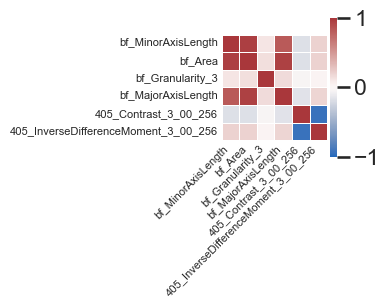

In [15]:
# Step 2: Calculate correlations among selected morphology features.
feature_matrix_numeric = df_features.drop(columns=["exp_id"], errors="ignore").apply(
    pd.to_numeric, errors="coerce"
)
correlation_features = [
    feature for feature in top_module_features
    if feature in set(module_feature_scores["feature"]) and feature in feature_matrix_numeric.columns
]
if len(correlation_features) < 2:
    raise ValueError("Fewer than two module SHAP features are available for the correlation matrix.")
feature_correlation = feature_matrix_numeric[correlation_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(
    feature_correlation, ax=ax, cmap="vlag", vmin=-1, vmax=1, center=0, square=True,
    cbar_kws={"shrink": 0.65, "pad": 0.02, "ticks": [-1, 0, 1]}, linewidths=0.5
)
ax.tick_params(axis="both", labelsize=8, pad=0.5, length=2, width=0.5)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "feature_correlation_matrix_top_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Section 4: Feature responses and representative cells

## Figure 5J-K and Supplementary Figure 5H: Feature responses and representative cells

1. Calculate module scores as means of per-gene standardized predicted expression and standardize the resulting scores across cells.
2. Plot feature responses using 1st/99th percentile clipping, min-max display normalization, Spearman tests, and centered 250-cell rolling means.
3. Define responsive ranges and select representative cells near the joint low and high percentile targets.
4. Use feature annotations to load corresponding image channels and create representative-cell montages when the optional HDF5 store is available.

**Dependency note:** module scores, top features, and responsive ranges are recomputed from the rerun before representative-cell selection. Plotting and cell selection consistently use the rerun module with the highest mean normalized SHAP for each feature.

In [16]:
# Step 1: Calculate module scores and feature-response profiles.
predicted_expression_gene_z = predicted_matrix.sub(predicted_matrix.mean(axis=0), axis=1)
predicted_expression_gene_z = predicted_expression_gene_z.div(
    predicted_matrix.std(axis=0).replace(0, np.nan), axis=1
)
module_gene_map = predicted_gene_clusters.groupby(cluster_column)["gene"].apply(list).to_dict()

module_score_rows = []
for cluster_id, genes in module_gene_map.items():
    available_genes = [gene for gene in genes if gene in predicted_expression_gene_z.columns]
    if len(available_genes) < 2:
        continue
    score = predicted_expression_gene_z[available_genes].mean(axis=1)
    score = (score - score.mean()) / score.std()
    module_score_rows.append(pd.DataFrame({
        "cell_id": score.index.astype(str),
        cluster_column: cluster_id,
        "cluster_zscore": score.values,
        "n_genes": len(available_genes),
    }))
if not module_score_rows:
    raise ValueError("No module has at least two predicted-expression genes.")
predicted_module_scores = pd.concat(module_score_rows, ignore_index=True)

available_shap_features = [
    feature for feature in dict.fromkeys(top_module_features)
    if feature in feature_matrix_numeric.columns
]
predicted_module_scores = predicted_module_scores.join(
    feature_matrix_numeric[available_shap_features], on="cell_id"
)
feature_plot_rows = []
for feature in available_shap_features:
    frame = predicted_module_scores[
        ["cell_id", cluster_column, "cluster_zscore", "n_genes", feature]
    ].dropna().rename(columns={feature: "feature_value"})
    frame["feature"] = feature
    feature_plot_rows.append(frame)
cluster_feature_plot_df = pd.concat(feature_plot_rows, ignore_index=True)

clip_bounds = (
    cluster_feature_plot_df.groupby("feature")["feature_value"].quantile([0.01, 0.99]).unstack()
    .rename(columns={0.01: "feature_clip_low", 0.99: "feature_clip_high"})
)
cluster_feature_plot_df = cluster_feature_plot_df.join(clip_bounds, on="feature")
cluster_feature_plot_df["feature_value_clipped"] = cluster_feature_plot_df["feature_value"].clip(
    lower=cluster_feature_plot_df["feature_clip_low"],
    upper=cluster_feature_plot_df["feature_clip_high"],
)
norm_bounds = cluster_feature_plot_df.groupby("feature")["feature_value_clipped"].agg(["min", "max"])
cluster_feature_plot_df = cluster_feature_plot_df.join(norm_bounds, on="feature", rsuffix="_bound")
feature_range = cluster_feature_plot_df["max"] - cluster_feature_plot_df["min"]
cluster_feature_plot_df["feature_value_norm"] = np.where(
    feature_range > 0,
    (cluster_feature_plot_df["feature_value_clipped"] - cluster_feature_plot_df["min"]) / feature_range,
    0.5,
)
cluster_feature_plot_df = cluster_feature_plot_df.drop(columns=["min", "max"])

spearman_rows = []
for (cluster_id, feature), group in cluster_feature_plot_df.groupby([cluster_column, "feature"]):
    correlation_df = group[["feature_value", "cluster_zscore", "n_genes"]].dropna()
    if len(correlation_df) < 3 or correlation_df["feature_value"].nunique() < 2:
        rho, p_value = np.nan, np.nan
    else:
        rho, p_value = spearmanr(correlation_df["feature_value"], correlation_df["cluster_zscore"])
    spearman_rows.append({
        cluster_column: cluster_id, "feature": feature, "spearman_r": rho,
        "spearman_r2": rho ** 2 if np.isfinite(rho) else np.nan,
        "spearman_p": p_value, "n_cells": len(correlation_df),
        "n_genes": int(correlation_df["n_genes"].max()) if not correlation_df.empty else 0,
    })
cluster_feature_spearman = pd.DataFrame(spearman_rows)

responsive_rows = []
best_feature_clusters = cluster_feature_spearman.merge(
    best_shap_cluster_by_feature, on="feature", how="inner"
)
best_feature_clusters = best_feature_clusters[
    best_feature_clusters[cluster_column] == best_feature_clusters["best_shap_cluster"]
].copy()
if set(best_feature_clusters["feature"]) != set(available_shap_features):
    raise ValueError("Every plotted feature must map to exactly one highest-SHAP canonical module.")
for row in best_feature_clusters.itertuples(index=False):
    feature = row.feature
    cluster_id = getattr(row, cluster_column)
    response_df = cluster_feature_plot_df[
        (cluster_feature_plot_df["feature"] == feature)
        & (cluster_feature_plot_df[cluster_column] == cluster_id)
    ].dropna(subset=["feature_value", "cluster_zscore"]).sort_values("feature_value").copy()
    smooth = response_df["cluster_zscore"].rolling(250, center=True, min_periods=25).mean()
    valid = smooth.notna()
    if valid.sum() >= 3:
        response_low, response_high = smooth[valid].quantile([0.10, 0.90])
        responsive_df = response_df.loc[smooth.between(response_low, response_high).fillna(False)]
    else:
        response_low, response_high = np.nan, np.nan
        responsive_df = response_df
    if responsive_df.empty:
        responsive_df = response_df
    responsive_rows.append({
        "feature": feature, cluster_column: cluster_id,
        "spearman_r": row.spearman_r, "spearman_r2": row.spearman_r2,
        "response_low": response_low, "response_high": response_high,
        "feature_min": responsive_df["feature_value"].min(),
        "feature_max": responsive_df["feature_value"].max(),
        "n_cells_in_range": len(responsive_df),
    })
responsive_feature_ranges = pd.DataFrame(responsive_rows)
cluster_feature_spearman.to_csv(
    ANALYSIS_OUTPUT_DIR / "rerun_module_feature_spearman.csv", index=False
)
responsive_feature_ranges.to_csv(
    ANALYSIS_OUTPUT_DIR / "rerun_responsive_feature_ranges.csv", index=False
)
display(cluster_feature_spearman.sort_values("spearman_r2", ascending=False))
display(responsive_feature_ranges)

,canonical_cluster,feature,spearman_r,spearman_r2,spearman_p,n_cells,n_genes
8,2,bf_Area,0.857061,0.734553,0.000000e+00,5069,91
11,2,bf_MinorAxisLength,0.821103,0.674209,0.000000e+00,5069,91
5,1,bf_MinorAxisLength,-0.819103,0.670930,0.000000e+00,5069,37
10,2,bf_MajorAxisLength,0.817155,0.667742,0.000000e+00,5069,91
2,1,bf_Area,-0.803859,0.646189,0.000000e+00,5069,37
4,1,bf_MajorAxisLength,-0.713228,0.508694,0.000000e+00,5069,37
17,3,bf_MinorAxisLength,0.563199,0.317193,0.000000e+00,5069,59
12,3,405_Contrast_3_00_256,-0.543425,0.295310,0.000000e+00,5069,59
13,3,405_InverseDifferenceMoment_3_00_256,0.541712,0.293452,0.000000e+00,5069,59
14,3,bf_Area,0.458771,0.210471,2.342711e-262,5069,59


,feature,canonical_cluster,spearman_r,spearman_r2,response_low,response_high,feature_min,feature_max,n_cells_in_range
0,bf_Area,2,0.857061,0.734553,-1.266364,1.007454,-2.836306,1.160061,4055
1,bf_MajorAxisLength,2,0.817155,0.667742,-1.220734,0.986391,-0.754126,1.173120,4055
2,bf_MinorAxisLength,2,0.821103,0.674209,-1.129622,1.044474,-5.183185,1.104666,4055
3,405_Contrast_3_00_256,3,-0.543425,0.295310,-0.616730,0.908904,-0.565797,17.192205,4055
4,405_InverseDifferenceMoment_3_00_256,3,0.541712,0.293452,-0.621926,0.822077,-1.721777,1.223244,4055
5,bf_Granularity_3,3,-0.022663,0.000514,-0.365380,0.158133,-0.056066,57.664652,4055


In [17]:
# Step 2: Select representative low- and high-response cells.
N_REPRESENTATIVE_CELLS = 6
representative_rows = []
for feature in available_shap_features:
    range_row = (
        responsive_feature_ranges[responsive_feature_ranges["feature"] == feature]
        .sort_values("spearman_r2", ascending=False).iloc[0]
    )
    best_cluster = int(range_row[cluster_column])
    rho = float(range_row["spearman_r"])
    candidates = (
        predicted_module_scores[predicted_module_scores[cluster_column] == best_cluster]
        [["cell_id", "cluster_zscore"]].rename(columns={"cluster_zscore": "prediction_score"})
        .merge(
            feature_matrix_numeric[[feature]].rename(columns={feature: "feature_value"}),
            left_on="cell_id", right_index=True, how="inner"
        )
        .dropna(subset=["prediction_score", "feature_value"])
    )
    candidates = candidates[candidates["feature_value"].between(
        float(range_row["feature_min"]), float(range_row["feature_max"])
    )].copy()
    if len(candidates) < 2 * N_REPRESENTATIVE_CELLS:
        raise ValueError(f"Too few responsive-range cells for {feature}: {len(candidates)}")

    low_quantile, high_quantile = 0.10, 0.90
    p50, p90, p95 = candidates["feature_value"].quantile([0.50, 0.90, 0.95])
    if np.isfinite(p90 - p50) and p90 > p50 and p95 - p90 > 5 * (p90 - p50):
        high_quantile = 0.95
    feature_low = candidates["feature_value"].quantile(low_quantile)
    feature_high = candidates["feature_value"].quantile(high_quantile)
    prediction_low = candidates["prediction_score"].quantile(0.10)
    prediction_high = candidates["prediction_score"].quantile(0.90)
    feature_scale = feature_high - feature_low
    prediction_scale = prediction_high - prediction_low
    if not np.isfinite(feature_scale) or feature_scale == 0:
        feature_scale = candidates["feature_value"].std()
    if not np.isfinite(prediction_scale) or prediction_scale == 0:
        prediction_scale = candidates["prediction_score"].std()

    if rho >= 0:
        low_group, high_group = "low_feature_low_prediction", "high_feature_high_prediction"
        low_prediction_target, high_prediction_target = prediction_low, prediction_high
    else:
        low_group, high_group = "low_feature_high_prediction", "high_feature_low_prediction"
        low_prediction_target, high_prediction_target = prediction_high, prediction_low
    candidates["low_target_distance"] = np.hypot(
        (candidates["feature_value"] - feature_low) / feature_scale,
        (candidates["prediction_score"] - low_prediction_target) / prediction_scale,
    )
    candidates["high_target_distance"] = np.hypot(
        (candidates["feature_value"] - feature_high) / feature_scale,
        (candidates["prediction_score"] - high_prediction_target) / prediction_scale,
    )
    low_cells = candidates.sort_values("low_target_distance").head(N_REPRESENTATIVE_CELLS).assign(
        group=low_group, rank=lambda frame: np.arange(1, len(frame) + 1)
    )
    high_cells = (
        candidates[~candidates["cell_id"].isin(low_cells["cell_id"])]
        .sort_values("high_target_distance").head(N_REPRESENTATIVE_CELLS)
        .assign(group=high_group, rank=lambda frame: np.arange(1, len(frame) + 1))
    )
    representative_rows.append(pd.concat([low_cells, high_cells], ignore_index=True).assign(
        feature=feature, responsive_cluster=best_cluster,
        responsive_feature_min=range_row["feature_min"],
        responsive_feature_max=range_row["feature_max"],
        feature_low_target_quantile=low_quantile,
        feature_high_target_quantile=high_quantile,
        feature_low_target=feature_low, feature_high_target=feature_high,
        responsive_spearman_r=rho, responsive_spearman_r2=range_row["spearman_r2"],
    ))
representative_cells = pd.concat(representative_rows, ignore_index=True)
representative_module_check = representative_cells[["feature", "responsive_cluster"]].drop_duplicates().merge(
    best_shap_cluster_by_feature[["feature", "best_shap_cluster"]], on="feature", how="left"
)
if not representative_module_check["responsive_cluster"].eq(
    representative_module_check["best_shap_cluster"]
).all():
    raise ValueError("Representative cells and feature-response plots must use the same highest-SHAP module.")
representative_cells.to_csv(
    ANALYSIS_OUTPUT_DIR / "rerun_representative_cells.csv", index=False
)
display(representative_cells)

,cell_id,prediction_score,feature_value,low_target_distance,high_target_distance,group,rank,feature,responsive_cluster,responsive_feature_min,responsive_feature_max,feature_low_target_quantile,feature_high_target_quantile,feature_low_target,feature_high_target,responsive_spearman_r,responsive_spearman_r2
0,13369,-1.425114,-0.746875,0.010946,1.403412,low_feature_low_prediction,1,bf_MinorAxisLength,2,-5.183185,1.104666,0.1,0.9,-0.756352,0.726873,0.821103,0.674209
1,4665,-1.474029,-0.765210,0.011845,1.425673,low_feature_low_prediction,2,bf_MinorAxisLength,2,-5.183185,1.104666,0.1,0.9,-0.756352,0.726873,0.821103,0.674209
2,16241,-1.428471,-0.774966,0.014660,1.417802,low_feature_low_prediction,3,bf_MinorAxisLength,2,-5.183185,1.104666,0.1,0.9,-0.756352,0.726873,0.821103,0.674209
3,14036,-1.469349,-0.774796,0.015006,1.428949,low_feature_low_prediction,4,bf_MinorAxisLength,2,-5.183185,1.104666,0.1,0.9,-0.756352,0.726873,0.821103,0.674209
4,16681,-1.491970,-0.765707,0.018358,1.430885,low_feature_low_prediction,5,bf_MinorAxisLength,2,-5.183185,1.104666,0.1,0.9,-0.756352,0.726873,0.821103,0.674209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,24319,1.155599,0.639799,1.392830,0.030510,high_feature_high_prediction,2,405_InverseDifferenceMoment_3_00_256,3,-1.721777,1.223244,0.1,0.9,-0.693514,0.681758,0.541712,0.293452
68,24144,1.144966,0.639777,1.389727,0.030824,high_feature_high_prediction,3,405_InverseDifferenceMoment_3_00_256,3,-1.721777,1.223244,0.1,0.9,-0.693514,0.681758,0.541712,0.293452
69,16629,1.167586,0.730552,1.442922,0.035815,high_feature_high_prediction,4,405_InverseDifferenceMoment_3_00_256,3,-1.721777,1.223244,0.1,0.9,-0.693514,0.681758,0.541712,0.293452
70,25382,1.243546,0.703376,1.450630,0.038993,high_feature_high_prediction,5,405_InverseDifferenceMoment_3_00_256,3,-1.721777,1.223244,0.1,0.9,-0.693514,0.681758,0.541712,0.293452


/tmp/ipykernel_1287178/2960835885.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


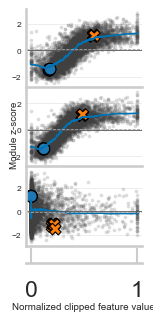

/tmp/ipykernel_1287178/2960835885.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


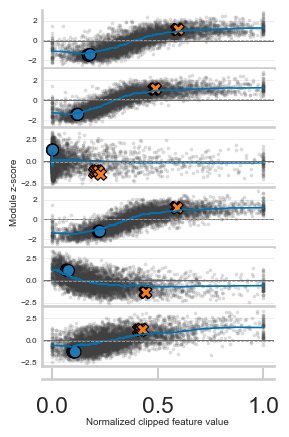

In [18]:
# Step 3: Plot compact feature-response panels for the selected modules.
compact_plot_df = cluster_feature_plot_df.merge(best_shap_cluster_by_feature, on="feature", how="inner")
compact_plot_df = compact_plot_df[
    compact_plot_df[cluster_column] == compact_plot_df["best_shap_cluster"]
].copy()


def plot_feature_responses(feature_order, filename, figsize):
    feature_order = [feature for feature in feature_order if feature in set(compact_plot_df["feature"])]
    if not feature_order:
        print(f"Skipping {filename}: no rerun-selected features are available.")
        return
    fig, axes = plt.subplots(
        len(feature_order) + 1, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [1] * len(feature_order) + [0.20], "hspace": 0.03},
    )
    plot_axes, xaxis_ax = np.atleast_1d(axes)[:-1], np.atleast_1d(axes)[-1]
    for ax, feature in zip(plot_axes, feature_order):
        feature_df = compact_plot_df[compact_plot_df["feature"] == feature].sort_values("feature_value_norm")
        cluster_id = int(feature_df["best_shap_cluster"].iloc[0])
        sns.scatterplot(
            data=feature_df, x="feature_value_norm", y="cluster_zscore",
            s=7, alpha=0.18, linewidth=0, color="0.25", ax=ax
        )
        highlight_ids = representative_cells[
            (representative_cells["feature"] == feature)
            & (representative_cells["responsive_cluster"] == cluster_id)
        ][["cell_id", "group"]]
        highlight_df = feature_df.merge(highlight_ids, on="cell_id", how="inner")
        sns.scatterplot(
            data=highlight_df, x="feature_value_norm", y="cluster_zscore", hue="group", style="group",
            s=70, edgecolor="black", linewidth=0.8, ax=ax, legend=False
        )
        trend = feature_df["cluster_zscore"].rolling(250, center=True, min_periods=25).mean()
        ax.plot(feature_df["feature_value_norm"], trend, color="#0072B2", linewidth=1.2)
        ax.axhline(0, color="0.35", linewidth=0.6)
        ax.axhline(feature_df["cluster_zscore"].median(), color="0.65", linewidth=0.6, linestyle="--")
        ax.set(xlabel="", ylabel="")
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
        ax.tick_params(axis="y", labelsize=6, length=2, pad=1)
        ax.grid(False)
        ax.yaxis.grid(True, color="0.9", linewidth=0.5)
        for spine_name in ["top", "right"]:
            ax.spines[spine_name].set_visible(False)
    xaxis_ax.set_ylim(0, 1)
    xaxis_ax.set_yticks([])
    xaxis_ax.set_xlabel("Normalized clipped feature value", fontsize=7, labelpad=1)
    for spine_name in ["top", "left", "right"]:
        xaxis_ax.spines[spine_name].set_visible(False)
    fig.supylabel("Module z-score", fontsize=7)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


compact_feature_order = (
    top3_module_features.sort_values(
        [cluster_column, "mean_normalized_shap", "feature"],
        ascending=[True, False, True],
    )
    .groupby(cluster_column, as_index=False).head(1)["feature"]
    .drop_duplicates().tolist()
)
plot_feature_responses(
    compact_feature_order,
    "predicted_expression_zpca_cluster_scores_best_shap_cluster_compact.png",
    (1.5, max(2, 1.1 * len(compact_feature_order))),
)
plot_feature_responses(
    top_module_features,
    "predicted_expression_zpca_cluster_scores_best_shap_cluster_compact_all.png",
    (3, max(3, 0.8 * len(top_module_features))),
)

In [19]:
# Step 4: Load image data and generate representative-cell montages.

def norm_minmax(img, verbose=True):
    if verbose:
        print(f'Image min {np.min(img)} max {np.max(img)}')
    img_max = np.max(img)
    if img_max > 0:
        if verbose:
            print('correcting')
        img = (img - np.min(img))/(np.max(img)-np.min(img))
    return img


def gen_montage_multich(cell_id_list, channel, h5_path, anno_list = None, ch_sep=False, verbose=True, crop_factor=0):
    print("v3 crop")
    img_dict = {ch: [] for ch in channel.keys()} 
    with h5py.File(h5_path, 'r') as dataset:
        if anno_list == 'cid':
            anno_list = cell_id_list
        if anno_list and len(anno_list) != len(cell_id_list):
            return None

        for l_id, cell_id in enumerate(cell_id_list):
            for ch in channel:
                cell_ds = dataset[str(cell_id)]
                foc_plane = str((cell_ds.attrs['focal_plane']))
                img = cell_ds[ch][foc_plane][()]
                if crop_factor != 0:
                    y,x = img.shape
                    startx = x//2 - crop_factor//2
                    starty = y//2 - crop_factor//2
                    img = img[starty:starty+crop_factor, startx:startx+crop_factor]

                #if np.max(img) != 1:
                #    img = img/255
                #img = img.astype('uint8')

                if channel[ch]["norm"] and not channel[ch]["col"] == "grey":
                    img = norm_minmax(img, verbose=verbose)
                if channel[ch]["col"] == "grey":
                    c_mean = np.mean(img)
                    adj_fact = 150 / c_mean if c_mean > 0 else 1
                    img = np.clip(img*adj_fact, 0, 255)/255#.astype(np.uint8)

                img.astype('float')

                img_dict[ch].append(img)

    for ch in img_dict.keys():
        img_mon = skimage_montage(img_dict[ch], grid_shape = (1, len(cell_id_list)))
        if not channel[ch]["norm"]:
            img_mon = norm_minmax(img_mon, verbose=verbose)
        img_dict[ch] = img_mon

    if ch_sep:
        for ch in img_dict.keys():
            img_mon = img_dict[ch]
            rgba_img = np.zeros((img_mon.shape[0], img_mon.shape[1], 3))
            img_color = channel[ch]["col"]
            if img_color == "red":
                rgba_img[..., 0] = img_mon
                rgba_img[..., 1] = img_mon * 0.2
                rgba_img[..., 2] = img_mon * 0.2

            if img_color == "green":
                rgba_img[..., 1] = img_mon
                rgba_img[..., 0] = img_mon * 0.2
                rgba_img[..., 2] = img_mon * 0.2

            if img_color == "blue":
                # Mix in some other colors to make the blue brighter
                rgba_img[..., 0] = img_mon * 0.2
                rgba_img[..., 1] = img_mon * 0.2
                rgba_img[..., 2] = img_mon

            if img_color == "grey":
                rgba_img[..., 0] = img_mon
                rgba_img[..., 1] = img_mon
                rgba_img[..., 2] = img_mon

            if img_color == "viridis":
                rgba_img = plt.colormaps["viridis"](img_mon)


            img_dict[ch] = rgba_img

        img_ar_all = [img for img in img_dict.values()]
        img_montage = skimage_montage(img_ar_all, grid_shape = (len(channel),1), channel_axis=3)
        return img_montage

    else:
        shape_x, shape_y = list(img_dict.values())[0].shape
        rgba_img = np.zeros((shape_x, shape_y, 3))
        for ch, _ in channel.items():
            img_color = channel[ch]["col"]
            img_mon = img_dict[ch]
            if img_color == "red":
                rgba_img[..., 0] = img_mon

            if img_color == "green":
                rgba_img[..., 1] = img_mon

            if img_color == "blue":
                rgba_img[..., 2] = img_mon

            if img_color == "virdis":
                print(img_mon)
                rgba_img = plt.colormaps["viridis"](img_mon)
                print(rgba_img)

            print("org: ", img_mon)
            print("1",img_color, rgba_img)

        return rgba_img


image_setup_by_annotation = {
    ("nucleus", "img"): ({"405": {"col": "viridis", "norm": True}}, 150),
    ("nucleus", "mask"): ({"nucmask": {"col": "grey", "norm": True}}, 150),
    ("bf", "img"): ({"bf": {"col": "grey", "norm": True}}, 200),
    ("bf", "mask"): ({"seg": {"col": "grey", "norm": True}}, 200),
}
montage_status_rows = []
if not CELL_IMAGE_H5.is_file():
    message = f"Skipping representative-cell montages: HDF5 not found at {CELL_IMAGE_H5}"
    print(message)
    montage_status_rows.append({"feature": "", "group": "", "status": "skipped", "reason": message})
elif not FEATURE_ANNOTATION_PATH.is_file():
    message = f"Skipping representative-cell montages: annotations not found at {FEATURE_ANNOTATION_PATH}"
    print(message)
    montage_status_rows.append({"feature": "", "group": "", "status": "skipped", "reason": message})
else:
    feature_annotations = pd.read_csv(FEATURE_ANNOTATION_PATH, dtype=str)
    if feature_annotations["Name"].duplicated().any():
        raise ValueError("Feature annotations contain duplicate names.")
    feature_annotation_lookup = feature_annotations.set_index("Name")[["Channel", "Type"]]
    for feature, feature_df in representative_cells.groupby("feature", sort=False):
        if feature not in feature_annotation_lookup.index:
            montage_status_rows.append({"feature": feature, "group": "", "status": "skipped", "reason": "missing annotation"})
            continue
        annotation = tuple(feature_annotation_lookup.loc[feature])
        if annotation not in image_setup_by_annotation:
            montage_status_rows.append({"feature": feature, "group": "", "status": "skipped", "reason": f"unsupported annotation {annotation}"})
            continue
        image_setup, crop_factor = image_setup_by_annotation[annotation]
        for group, group_df in feature_df.groupby("group", sort=False):
            cell_ids = group_df.sort_values("rank")["cell_id"].tolist()
            try:
                montage = gen_montage_multich(
                    cell_ids, image_setup, str(CELL_IMAGE_H5), "cid",
                    ch_sep=True, verbose=False, crop_factor=crop_factor
                )
            except (KeyError, OSError, ValueError) as exc:
                montage_status_rows.append({"feature": feature, "group": group, "status": "skipped", "reason": str(exc)})
                continue
            fig = plt.figure(figsize=(2, 2), dpi=400)
            ax = fig.add_axes([0, 0, 1, 1])
            ax.axis("off")
            ax.imshow(montage, cmap="magma")
            fig.savefig(
                FIGURE_DIR / f"ExampleImg_feature_{feature}_{group}.png",
                dpi=300, bbox_inches="tight"
            )
            plt.show()
            montage_status_rows.append({"feature": feature, "group": group, "status": "generated", "reason": ""})
montage_status = pd.DataFrame(montage_status_rows)
montage_status.to_csv(ANALYSIS_OUTPUT_DIR / "rerun_montage_status.csv", index=False)
display(montage_status)

Skipping representative-cell montages: HDF5 not found at /home/bues/iris_DataManagement/geneexp_data/ds_tools/IRIS/2_Cellcycle/04_Feature_analysis/inputs/fucci_final_nucmask.h5


,feature,group,status,reason
0,,,skipped,Skipping representative-cell montages: HDF5 no...
